Author:  
Manuel Eugenio Morocho Cayamcela, PhD

## Exploratory Analysis of the Titanic Data

The Titanic was a famous ocean liner that tragically sank on its maiden voyage in 1912. Considered at the time to be the largest and most luxurious ship in the world, the Titanic was a symbol of the opulence and technological progress of the era.

On April 10, 1912, the Titanic departed from Southampton, England, bound for New York. However, on the night of April 14 to 15, the ship struck an iceberg in the North Atlantic and sank within hours. This disaster resulted in the deaths of more than 1,500 people, making it one of the deadliest maritime tragedies in history.

### **Introduction:**

In this reading, which is part of the first week of the Fundamentals of Artificial Intelligence module, we will delve into the world of extracting information from data. The main goal is to introduce students to the tools and techniques needed to analyze and visualize basic data.

Analyzing the Titanic data, such as the dataset used in this Jupyter Notebook, allows us to explore different aspects of this tragic event. We can investigate the correlation between survival and variables such as the class passengers traveled in, gender, age, among others. We can also use visualization tools to graphically represent the data and obtain valuable insights into the patterns and characteristics of the Titanic's passengers.

During this activity, we will focus on two main objectives:

1. Test the theory that there is a correlation between survivors and the class they traveled in. To do this, we will analyze the data from the famous Titanic shipwreck and explore whether the class passengers traveled in had any influence on their survival.

2. Find out whether more men died than women in the shipwreck. Through data analysis, we will try to determine whether there is a significant difference in the survival rate between men and women.

The following are the steps needed to carry out this activity:

- We will start by importing the Titanic dataset, which is in CSV format. We will use the pandas library to load the data into a DataFrame so we can manipulate and analyze it.

- Once we have imported the data, we will perform an exploratory analysis to better understand the structure and characteristics of the dataset. This will include displaying basic descriptive statistics, identifying missing values, and exploring the variables relevant to our objectives.

- To make the analysis more didactic and understandable, some data can be represented graphically. This will include creating bar charts and other visualizations to help us analyze the correlation between variables and answer our research questions.

Each row represents a Titanic passenger, and each column represents a characteristic of that passenger, such as age, sex, passenger class, etc. 

The Titanic dataset contains the following columns:

1. `PassengerId`: A unique identifier for each passenger.
2. `Survived`: Whether the passenger survived or not (0 = No, 1 = Yes).
3. `Pclass`: The passenger's ticket class (1 = First, 2 = Second, 3 = Third).
4. `Name`: The passenger's name.
5. `Sex`: The passenger's sex.
6. `Age`: The passenger's age.
7. `SibSp`: The number of siblings or spouses the passenger had aboard the Titanic.
8. `Parch`: The number of parents or children the passenger had aboard the Titanic.
9. `Ticket`: The passenger's ticket number.
10. `Fare`: The fare the passenger paid for the ticket.
11. `Cabin`: The passenger's cabin number.
12. `Embarked`: The port where the passenger boarded (C = Cherbourg, Q = Queenstown, S = Southampton).

### Phase I: Data Loading and Exploration

In [1]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Load dataset
titanic = pd.read_csv('../../Datasets/titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Data types and non-null counts
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Summary statistics
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Check missing values
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Hypothesis Evaluation

#### Hypothesis 1: Women had a higher probability of survival

There is an old conspiracy theory suggesting that being female gave you a higher chance of survival. Let's check whether this hypothesis holds true.

In [6]:
# Survival rate by sex
titanic.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

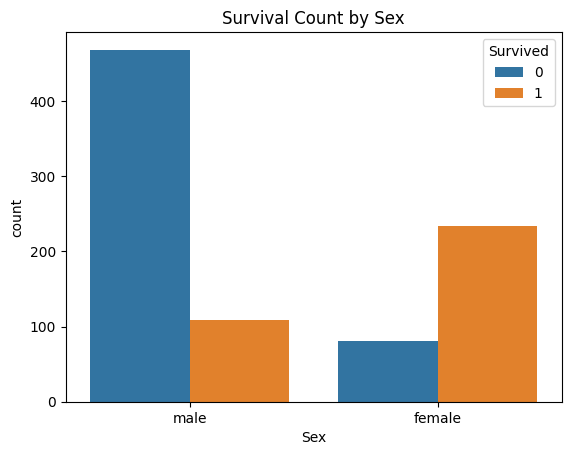

In [7]:
# Visualize survival counts by sex
sns.countplot(x='Sex', hue='Survived', data=titanic)
plt.title('Survival Count by Sex')
plt.show()

**Conclusion:** Women had a much higher survival rate (~74%) than men (~19%), confirming the hypothesis — women were given priority during the evacuation.

#### Hypothesis 2: Traveling in first class gave you a higher probability of survival

Another hypothesis we can test is whether there is a relationship between the class Titanic passengers traveled in and their survival rate. To investigate this relationship, determine whether there is a significant difference in the survival rate between the different classes.

In [8]:
# Survival rate by passenger class
titanic.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

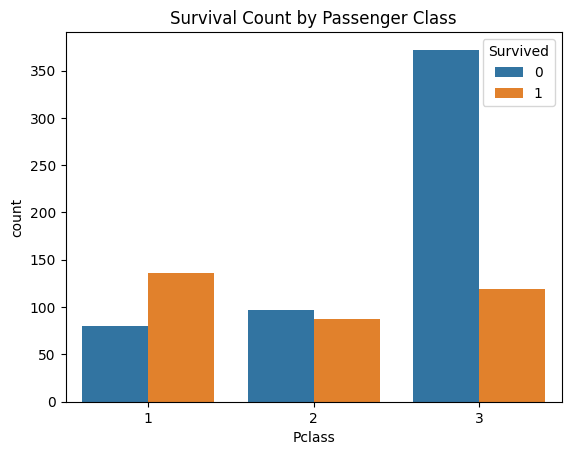

In [9]:
# Visualize survival counts by class
sns.countplot(x='Pclass', hue='Survived', data=titanic)
plt.title('Survival Count by Passenger Class')
plt.show()

**Conclusion:** Survival rate decreases as class goes down — 1st class ~63%, 2nd class ~47%, 3rd class ~24%, confirming the hypothesis.